# **Section 1: Prepare Dashboard Data**

In [24]:
import matplotlib.pyplot as plt
import pandas as pd
# KPIs
total_patients = len(patient_df)
completed = patient_df['treatment_completed'].sum()
conversion_rate = completed / total_patients * 100
total_revenue = treatment_df['actual_revenue_inr'].sum()
# Funnel
funnel = pd.DataFrame({
    'Stage': ['Inquiry','Consultation','Quote','Treatment'],
    'Count': [
        len(patient_df),
        patient_df['consultation_booked'].sum(),
        patient_df['quote_shared'].sum(),
        patient_df['treatment_completed'].sum()
    ]
})
# Provider
provider_dashboard = (
    patient_df.groupby('provider_id')['treatment_completed']
    .mean()
    .mul(100)
    .reset_index(name='conversion_rate')
    .sort_values('conversion_rate', ascending=False)
    .head(10)
)
# Country
country_dashboard = (
    patient_df.groupby('country')['treatment_completed']
    .mean()
    .mul(100)
    .reset_index(name='conversion_rate')
)
# Communication
channel = (
    comm_df['channel']
    .value_counts()
    .reset_index()
)
channel.columns = ['Channel','Interactions']

# **Section 2: Executive Dashboard**

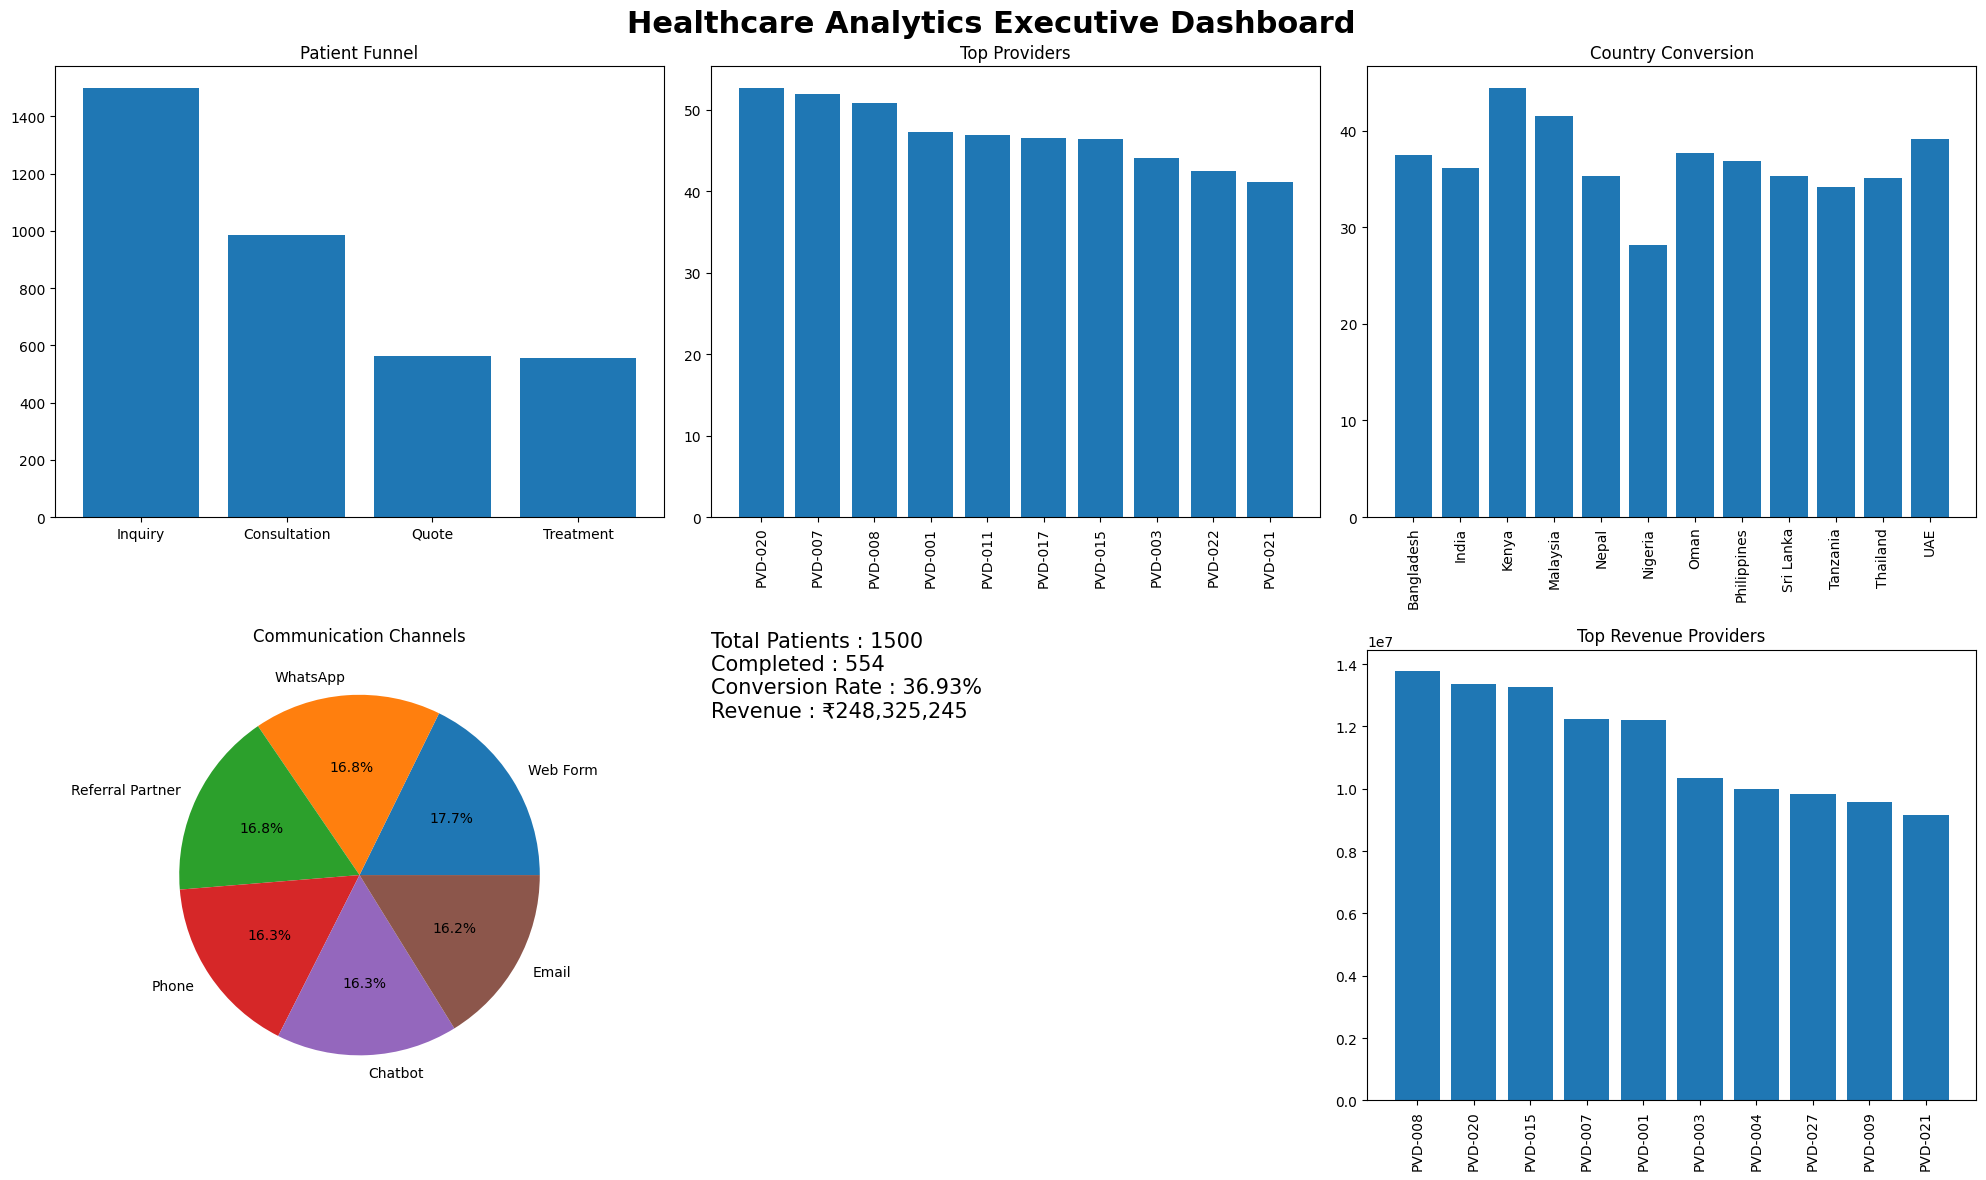

In [25]:
fig, axes = plt.subplots(2,3, figsize=(20,12))
# Funnel
axes[0,0].bar(
    funnel['Stage'],
    funnel['Count']
)
axes[0,0].set_title("Patient Funnel")
# Provider
axes[0,1].bar(
    provider_dashboard['provider_id'].astype(str),
    provider_dashboard['conversion_rate']
)
axes[0,1].set_title("Top Providers")
axes[0,1].tick_params(axis='x', rotation=90)
# Country
axes[0,2].bar(
    country_dashboard['country'],
    country_dashboard['conversion_rate']
)
axes[0,2].set_title("Country Conversion")
axes[0,2].tick_params(axis='x', rotation=90)
# Communication
axes[1,0].pie(
    channel['Interactions'],
    labels=channel['Channel'],
    autopct='%1.1f%%'
)
axes[1,0].set_title("Communication Channels")
# KPI Text
axes[1,1].axis('off')
kpi_text = f"""
Total Patients : {total_patients}
Completed : {completed}
Conversion Rate : {conversion_rate:.2f}%
Revenue : ₹{total_revenue:,.0f}
"""
axes[1,1].text(
    0,
    0.8,
    kpi_text,
    fontsize=15
)
# Revenue by Provider
provider_revenue = (
    treatment_df.groupby('provider_id')
    ['actual_revenue_inr']
    .sum()
    .reset_index()
    .sort_values(
        'actual_revenue_inr',
        ascending=False
    )
    .head(10)
)
axes[1,2].bar(
    provider_revenue['provider_id'].astype(str),
    provider_revenue['actual_revenue_inr']
)
axes[1,2].set_title("Top Revenue Providers")
axes[1,2].tick_params(axis='x', rotation=90)
plt.suptitle(
    "Healthcare Analytics Executive Dashboard",
    fontsize=22,
    fontweight='bold'
)
plt.tight_layout()
plt.show()